# YouTube Shorts 分析報告
## @Lisa_sung、@蜡笔小锋 二頻道比較

本報告基於 YouTube Data API v3 抓取的兩個頻道 Shorts 影片資料，進行深入統計分析與比較。

**核心研究問題：**
- Lisa_sung 與 蜡笔小锋 在 Shorts 內容策略上有何差異？
- 標題長度、標籤數量對兩個頻道的觀看數影響是否不同？
- 影片長度、發布頻率是否在兩個頻道間有顯著差異？
- 兩個頻道的粉絲互動指標（按讚、留言）有何特徵？

## 1. 匯入所需函式庫

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 設定中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

print("✓ 所有函式庫載入完成")

✓ 所有函式庫載入完成


## 2. 載入 CSV 資料

In [6]:
# 載入資料
df = pd.read_csv('../data/processed/channel_videos_20260526-030644.csv', encoding='utf-8')
df_channels = pd.read_csv('../data/processed/channels_20260526-030644.csv', encoding='utf-8')

print(f"✓ 資料載入成功")
print(f"  - 影片資料：{len(df)} 列")
print(f"  - 頻道資料：{len(df_channels)} 列")
print(f"\n頻道列表：")
print(df['channel_title'].unique())

✓ 資料載入成功
  - 影片資料：410 列
  - 頻道資料：3 列

頻道列表：
['Ju茱莉亞林' 'Lisa Sung' '蜡笔小锋']


## 3. 篩選 Lisa_sung 與 蜡笔小锋 相關資料

In [11]:
# 複製一份用於清理
df_clean = df.copy()

# 轉換日期欄位
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 建立派生欄位
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)
df_clean['tag_count'] = df_clean['title'].fillna('').apply(lambda x: x.count('#'))

# 篩選目標頻道與 Shorts（duration_sec <= 180）
target_channels = ['Lisa Sung', '蜡笔小锋']
df_shorts = df_clean[
    (df_clean['channel_title'].isin(target_channels)) & 
    (df_clean['duration_sec'] <= 180)]

## 4. 基本統計資訊

In [14]:
# 整體統計
print("=" * 80)
print("整體 Shorts 主要指標統計 (Duration <= 180s)")
print("=" * 80)

metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec']
for metric in metrics:
    if metric in df_shorts.columns:
        data = df_shorts[metric].dropna()
        print(f"\n{metric}:")
        print(f"  - 平均值: {data.mean():,.0f}")
        print(f"  - 中位數: {data.median():,.0f}")
        print(f"  - 最小值: {data.min():,.0f}")
        print(f"  - 最大值: {data.max():,.0f}")
        print(f"  - 標準差: {data.std():,.0f}")

# 頻道級統計
print("\n" + "=" * 80)
print("頻道級別統計")
print("=" * 80)

print("\n影片數量與觀看指標（按頻道）：")
for channel in sorted(df_shorts['channel_title'].unique()):
    ch_data = df_shorts[df_shorts['channel_title'] == channel]
    ch_info = df_channels[df_channels['title'] == channel]
    
    print(f"\n{channel}:")
    print(f"  【Shorts 資料】")
    print(f"    - Shorts 數量: {len(ch_data)}")
    print(f"    - 平均觀看數: {ch_data['view_count'].mean():,.0f}")
    print(f"    - 平均按讚數: {ch_data['like_count'].mean():,.0f}")
    print(f"    - 平均留言數: {ch_data['comment_count'].mean():,.0f}")
    print(f"    - 平均標題長度: {ch_data['title_length'].mean():.1f} 字")
    print(f"    - 平均標籤數: {ch_data['tag_count'].mean():.2f} 個")
    
    if not ch_info.empty:
        print(f"  【頻道級資訊】")
        print(f"    - 總訂閱數: {ch_info['subscriber_count'].iloc[0]:,.0f}")
        print(f"    - 總影片數: {ch_info['video_count'].iloc[0]:,.0f}")
        print(f"    - 總觀看數: {ch_info['view_count'].iloc[0]:,.0f}")
        print(f"    - 頻道開設於: {ch_info['published_at'].iloc[0]}")

整體 Shorts 主要指標統計 (Duration <= 180s)

view_count:
  - 平均值: 340,902
  - 中位數: 204,406
  - 最小值: 4,987
  - 最大值: 4,590,299
  - 標準差: 501,396

like_count:
  - 平均值: 4,972
  - 中位數: 3,225
  - 最小值: 67
  - 最大值: 71,551
  - 標準差: 7,349

comment_count:
  - 平均值: 92
  - 中位數: 60
  - 最小值: 4
  - 最大值: 1,165
  - 標準差: 121

duration_sec:
  - 平均值: 98
  - 中位數: 87
  - 最小值: 8
  - 最大值: 180
  - 標準差: 38

頻道級別統計

影片數量與觀看指標（按頻道）：

Lisa Sung:
  【Shorts 資料】
    - Shorts 數量: 167
    - 平均觀看數: 344,769
    - 平均按讚數: 5,292
    - 平均留言數: 118
    - 平均標題長度: 21.7 字
    - 平均標籤數: 0.31 個
  【頻道級資訊】
    - 總訂閱數: 66,400
    - 總影片數: 169
    - 總觀看數: 57,569,121
    - 頻道開設於: 2016-01-06T22:46:06Z

蜡笔小锋:
  【Shorts 資料】
    - Shorts 數量: 113
    - 平均觀看數: 335,187
    - 平均按讚數: 4,500
    - 平均留言數: 54
    - 平均標題長度: 41.0 字
    - 平均標籤數: 4.31 個
  【頻道級資訊】
    - 總訂閱數: 67,900
    - 總影片數: 418
    - 總觀看數: 109,194,948
    - 頻道開設於: 2025-07-18T11:16:51.262568Z


## 5. 兩頻道差異統計檢定

In [19]:
from scipy.stats import ttest_ind, mannwhitneyu

print("=" * 80)
print("兩頻道獨立樣本檢定 (Independent Sample Tests)")
print("=" * 80)

ch1_name, ch2_name = sorted(df_shorts['channel_title'].unique())
ch1_data = df_shorts[df_shorts['channel_title'] == ch1_name]
ch2_data = df_shorts[df_shorts['channel_title'] == ch2_name]

# 檢查常態性並選擇適當檢定
test_metrics = ['view_count', 'like_count', 'comment_count', 'title_length', 'tag_count']

print(f"\n【樣本概況】")
print(f"  {ch1_name}: n = {len(ch1_data)}")
print(f"  {ch2_name}: n = {len(ch2_data)}")

print(f"\n【假設檢定結果】")
print(f"（使用 Mann-Whitney U 檢定，適合非常態分佈的資料）\n")

for metric in test_metrics:
    data1 = ch1_data[metric].dropna()
    data2 = ch2_data[metric].dropna()
    
    if len(data1) > 0 and len(data2) > 0:
        # Mann-Whitney U 檢定
        u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        
        print(f"{metric}:")
        print(f"  {ch1_name} 平均: {data1.mean():,.2f}  |  {ch2_name} 平均: {data2.mean():,.2f}")
        print(f"  p-value = {p_val:.4e} {sig}")
        print()

兩頻道獨立樣本檢定 (Independent Sample Tests)

【樣本概況】
  Lisa Sung: n = 167
  蜡笔小锋: n = 113

【假設檢定結果】
（使用 Mann-Whitney U 檢定，適合非常態分佈的資料）

view_count:
  Lisa Sung 平均: 344,768.50  |  蜡笔小锋 平均: 335,187.13
  p-value = 6.8241e-01 ns

like_count:
  Lisa Sung 平均: 5,291.60  |  蜡笔小锋 平均: 4,500.19
  p-value = 1.3060e-02 *

comment_count:
  Lisa Sung 平均: 118.11  |  蜡笔小锋 平均: 54.49
  p-value = 2.7101e-11 ***

title_length:
  Lisa Sung 平均: 21.72  |  蜡笔小锋 平均: 41.01
  p-value = 3.2281e-31 ***

tag_count:
  Lisa Sung 平均: 0.31  |  蜡笔小锋 平均: 4.31
  p-value = 1.5352e-48 ***



## 6. 發佈時間趨勢分析

In [22]:
# 提取發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()

# 按日期統計
daily_stats = df_shorts.groupby(['pub_date', 'channel_title']).agg({
    'video_id': 'count',
    'view_count': 'mean',
    'like_count': 'mean',
    'comment_count': 'mean'
}).rename(columns={'video_id': 'video_count'})

print("按發佈日期的趨勢（按頻道分組）：")
print(daily_stats.round(0))
print()

# 按小時統計
hourly_stats = df_shorts.groupby(['pub_hour', 'channel_title']).agg({
    'view_count': 'mean',
    'like_count': 'mean',
    'comment_count': 'mean'
})

print("按發佈時段的趨勢（按頻道分組）：")
print(hourly_stats.round(0))

按發佈日期的趨勢（按頻道分組）：
                          video_count  view_count  like_count  comment_count
pub_date   channel_title                                                    
2025-06-07 Lisa Sung                1   4522893.0     67184.0          533.0
2025-06-11 Lisa Sung                1    313156.0      4848.0           98.0
2025-06-12 Lisa Sung                1    332612.0      5181.0           94.0
2025-06-13 Lisa Sung                1    594274.0      8592.0          125.0
2025-06-14 Lisa Sung                1    174582.0      2625.0           47.0
...                               ...         ...         ...            ...
2026-05-21 蜡笔小锋                     1    309313.0      3957.0           24.0
2026-05-22 蜡笔小锋                     1    102926.0      1747.0           56.0
2026-05-23 蜡笔小锋                     1    210212.0      2495.0           17.0
2026-05-24 蜡笔小锋                     1     72185.0       958.0            4.0
2026-05-25 蜡笔小锋                     1    142470.0      2393

## 7. 互動指標相關性分析

In [25]:
# 選取需要分析的數值欄位
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec', 
                 'title_length', 'tag_count']
df_corr = df_shorts[analysis_cols].copy()

# 計算相關係數矩陣
corr_matrix = df_corr.corr()

print("=" * 80)
print("互動指標相關係數矩陣（整體）")
print("=" * 80)
print(corr_matrix.round(3))
print()

# 與觀看數的相關性
print("與觀看數（view_count）的相關性：")
view_corr = corr_matrix['view_count'].sort_values(ascending=False)
print(view_corr)
print()

# Pearson 相關係數檢定
print("=" * 80)
print("相關性顯著性檢定 (Pearson)")
print("=" * 80)
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    data = df_shorts[[col, 'view_count']].dropna()
    if len(data) > 2:
        corr, p_value = stats.pearsonr(data[col], data['view_count'])
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
        print(f"{col:20s}: r = {corr:7.4f}, p-value = {p_value:.4e} {sig}")

互動指標相關係數矩陣（整體）
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.987          0.521         0.039   
like_count          0.987       1.000          0.537         0.033   
comment_count       0.521       0.537          1.000        -0.122   
duration_sec        0.039       0.033         -0.122         1.000   
title_length        0.057       0.034         -0.141         0.377   
tag_count           0.123       0.086         -0.142         0.465   

               title_length  tag_count  
view_count            0.057      0.123  
like_count            0.034      0.086  
comment_count        -0.141     -0.142  
duration_sec          0.377      0.465  
title_length          1.000      0.683  
tag_count             0.683      1.000  

與觀看數（view_count）的相關性：
view_count       1.000000
like_count       0.987470
comment_count    0.520561
tag_count        0.123218
title_length     0.057306
duration_sec     0.039188
Name: view_count, dtype: flo

## 8. 視覺化：前 10 名影片表現

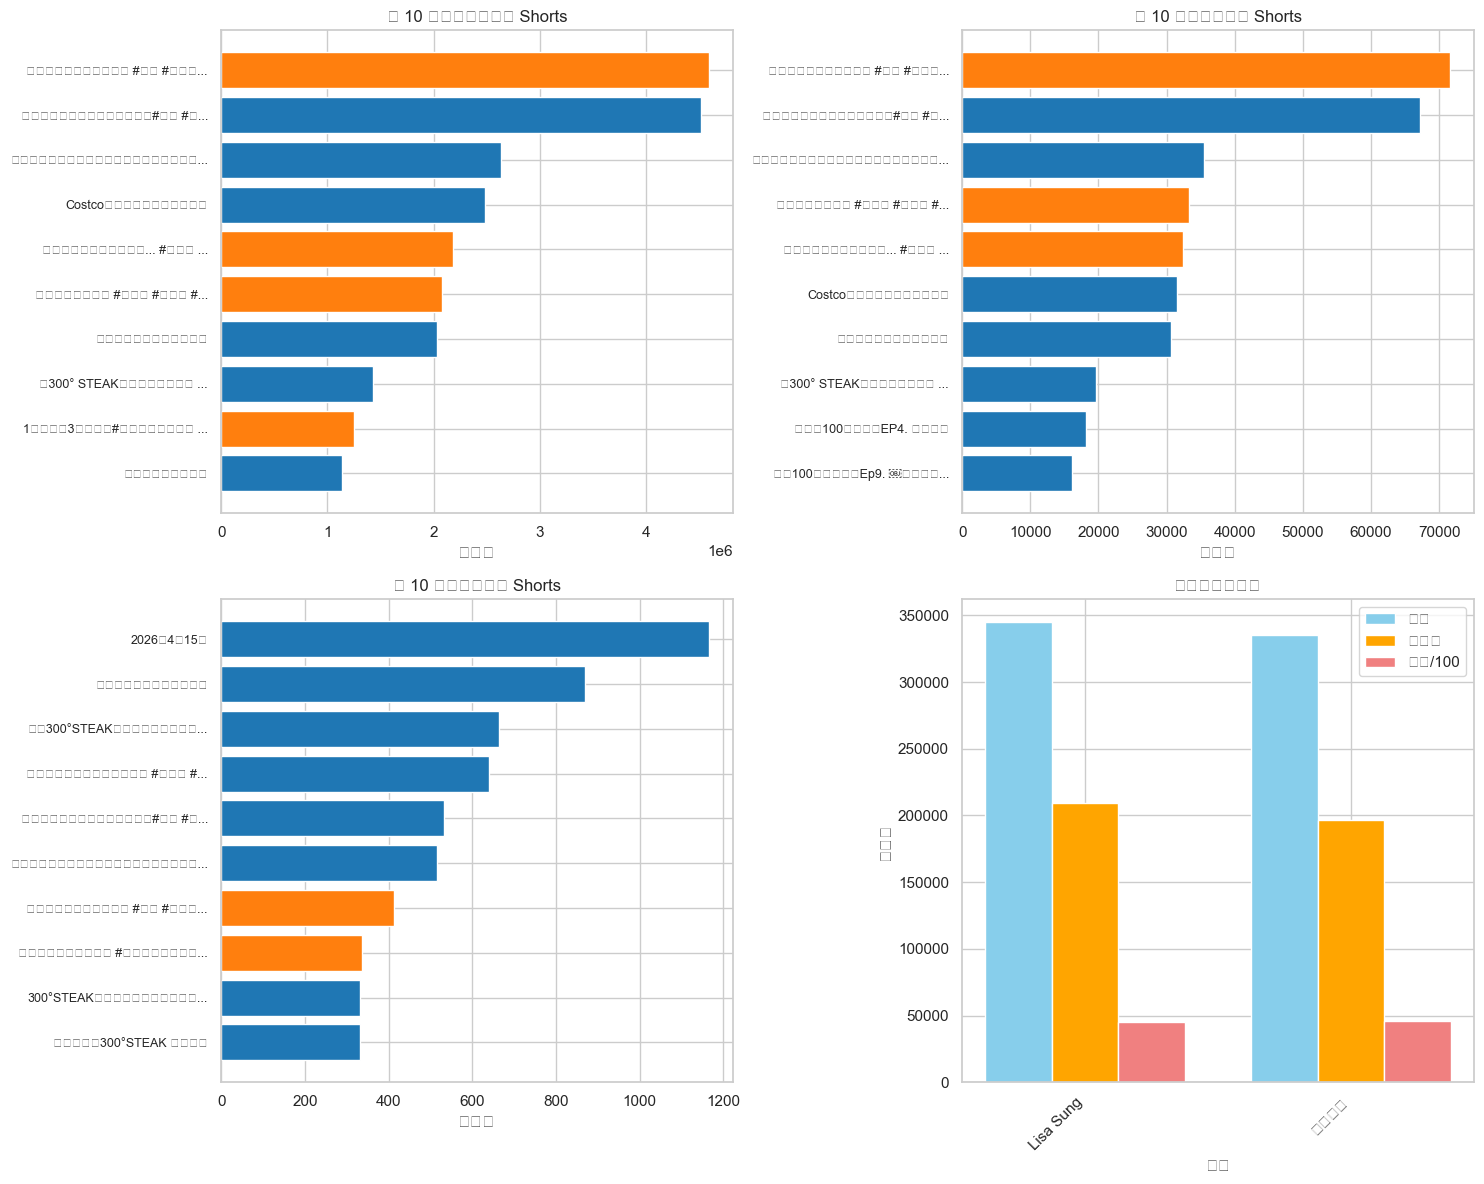

✓ 視覺化完成


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 前 10 觀看數
top10_views = df_shorts.nlargest(10, 'view_count')
ax = axes[0, 0]
colors = ['#1f77b4' if ch == ch1_name else '#ff7f0e' for ch in top10_views['channel_title']]
ax.barh(range(len(top10_views)), top10_views['view_count'].values, color=colors)
ax.set_yticks(range(len(top10_views)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_views['title'].values], fontsize=9)
ax.set_xlabel('觀看數')
ax.set_title('前 10 名最多觀看數的 Shorts')
ax.invert_yaxis()

# 前 10 按讚數
top10_likes = df_shorts.nlargest(10, 'like_count')
ax = axes[0, 1]
colors = ['#1f77b4' if ch == ch1_name else '#ff7f0e' for ch in top10_likes['channel_title']]
ax.barh(range(len(top10_likes)), top10_likes['like_count'].values, color=colors)
ax.set_yticks(range(len(top10_likes)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_likes['title'].values], fontsize=9)
ax.set_xlabel('按讚數')
ax.set_title('前 10 名最多按讚的 Shorts')
ax.invert_yaxis()

# 前 10 留言數
top10_comments = df_shorts.nlargest(10, 'comment_count')
ax = axes[1, 0]
colors = ['#1f77b4' if ch == ch1_name else '#ff7f0e' for ch in top10_comments['channel_title']]
ax.barh(range(len(top10_comments)), top10_comments['comment_count'].values, color=colors)
ax.set_yticks(range(len(top10_comments)))
ax.set_yticklabels([f"{t[:20]}..." if len(t) > 20 else t for t in top10_comments['title'].values], fontsize=9)
ax.set_xlabel('留言數')
ax.set_title('前 10 名最多留言的 Shorts')
ax.invert_yaxis()

# 頻道平均觀看數比較
ax = axes[1, 1]
channel_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean', 'median', 'max']).reset_index()
x = range(len(channel_summary))
width = 0.25
ax.bar([i - width for i in x], channel_summary['mean'], width, label='平均', color='skyblue')
ax.bar(x, channel_summary['median'], width, label='中位數', color='orange')
ax.bar([i + width for i in x], channel_summary['max']/100, width, label='最大/100', color='lightcoral')
ax.set_xlabel('頻道')
ax.set_ylabel('觀看數')
ax.set_title('頻道觀看數統計')
ax.set_xticks(x)
ax.set_xticklabels(channel_summary['channel_title'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

print("✓ 視覺化完成")

In [37]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 準備迴歸數據（移除遺失值）
df_reg = df_shorts[['view_count', 'duration_sec', 'title_length', 'tag_count', 'channel_title']].dropna()

print(f"迴歸分析樣本數：{len(df_reg)}")
print()

# 標準化自變數
scaler = StandardScaler()
features = ['duration_sec', 'title_length', 'tag_count']
df_reg_scaled = df_reg.copy()
df_reg_scaled[features] = scaler.fit_transform(df_reg[features])

# ==============================================================================
# 模型 1：簡單線性迴歸（連續變數）
# ==============================================================================
print("=" * 80)
print("模型 1：簡單線性迴歸（連續變數）")
print("=" * 80)

# 使用公式寫法，自動包含截距項
formula1 = 'view_count ~ duration_sec + title_length + tag_count'
model1 = sm.ols(formula=formula1, data=df_reg_scaled).fit()
print(model1.summary())

print("\n迴歸係數解釋（標準化）：")
for col in features:
    coef = model1.params[col]
    pval = model1.pvalues[col]
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
    print(f"  {col}: {coef:+.4f} (p={pval:.4e}) {sig}")

# ==============================================================================
# 模型 2：包含頻道虛擬變數
# ==============================================================================
print("\n" + "=" * 80)
print("模型 2：包含頻道控制變數")
print("=" * 80)

# 加入 C(channel_title) 告訴模型這是一個類別變數，它會自動轉換成 Dummy Variables
formula2 = 'view_count ~ duration_sec + title_length + tag_count + C(channel_title)'
model2 = sm.ols(formula=formula2, data=df_reg_scaled).fit()
print(model2.summary())

# ==============================================================================
# 模型比較
# ==============================================================================
print("\n" + "=" * 80)
print("模型比較")
print("=" * 80)
print(f"模型 1 R² = {model1.rsquared:.4f}, 調整 R² = {model1.rsquared_adj:.4f}")
print(f"模型 2 R² = {model2.rsquared:.4f}, 調整 R² = {model2.rsquared_adj:.4f}")

# ==============================================================================
# 計算 VIF (Variance Inflation Factor)
# ==============================================================================
print("\n" + "=" * 80)
print("多重共線性檢驗 (VIF)")
print("=" * 80)

# 直接從 model1 提取內部生成的設計矩陣 (exog) 進行 VIF 計算
X_exog = model1.model.exog
X_names = model1.model.exog_names

vif_data = pd.DataFrame()
vif_data["Variable"] = X_names[1:]  # 略過截距項 (Intercept)
vif_data["VIF"] = [variance_inflation_factor(X_exog, i) for i in range(1, X_exog.shape[1])]
print(vif_data.to_string(index=False))

迴歸分析樣本數：280

模型 1：簡單線性迴歸（連續變數）
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.574
Date:                Wed, 27 May 2026   Prob (F-statistic):              0.196
Time:                        13:41:23   Log-Likelihood:                -4069.5
No. Observations:                 280   AIC:                             8147.
Df Residuals:                     276   BIC:                             8161.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3.4

## 11. 迴歸結果視覺化

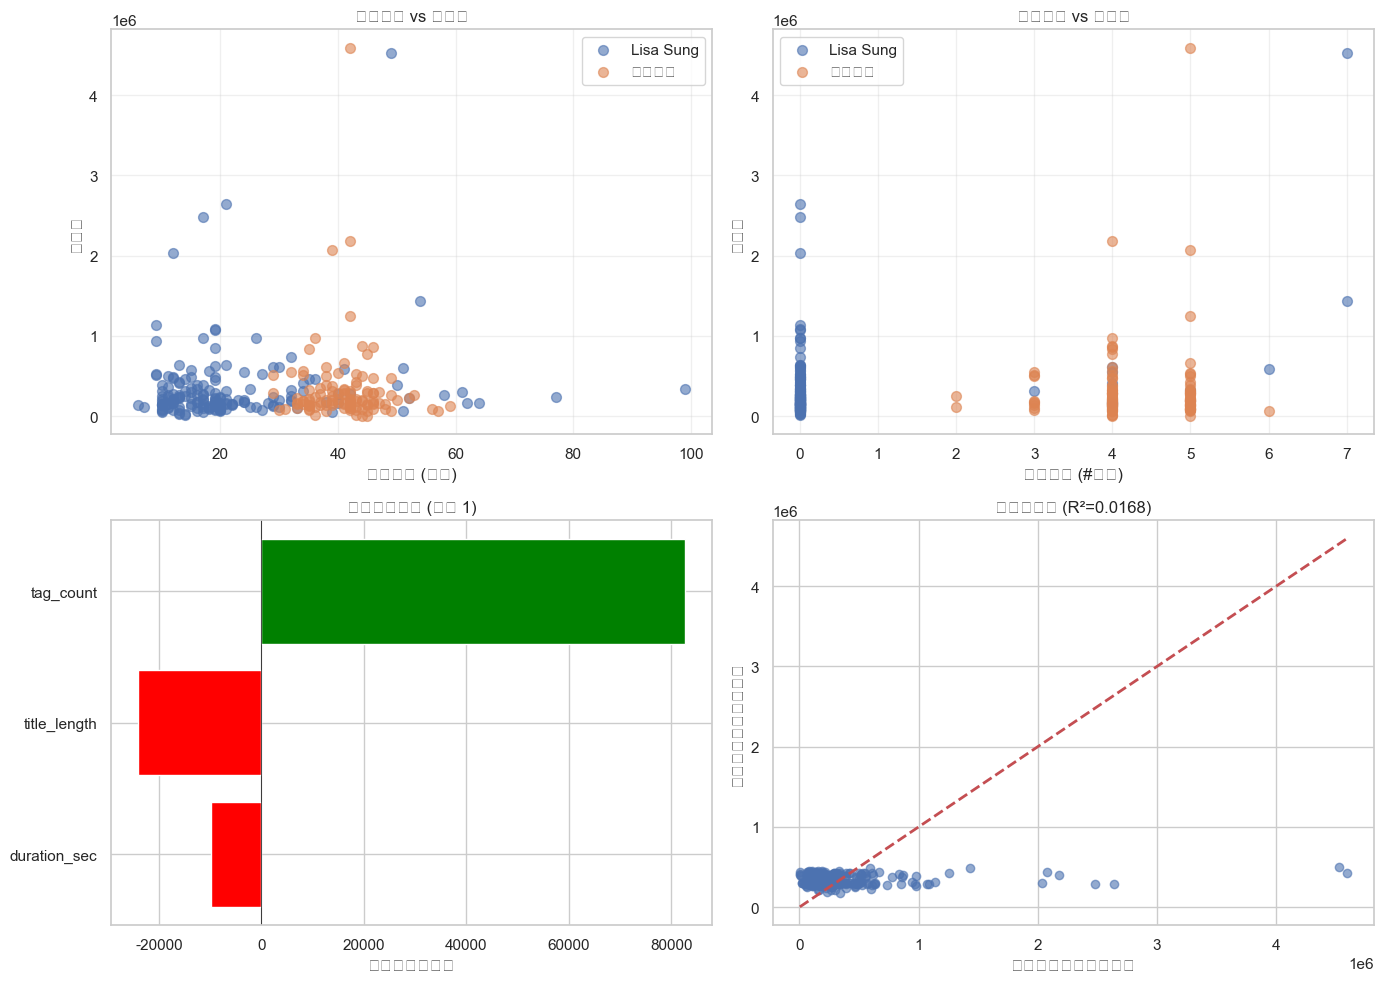

✓ 迴歸分析結果視覺化完成


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 標題長度與觀看數
ax = axes[0, 0]
for channel in sorted(df_shorts['channel_title'].unique()):
    ch_data = df_shorts[df_shorts['channel_title'] == channel]
    ax.scatter(ch_data['title_length'], ch_data['view_count'], 
              alpha=0.6, label=channel, s=50)
ax.set_xlabel('標題長度 (字數)')
ax.set_ylabel('觀看數')
ax.set_title('標題長度 vs 觀看數')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. 標籤數量與觀看數
ax = axes[0, 1]
for channel in sorted(df_shorts['channel_title'].unique()):
    ch_data = df_shorts[df_shorts['channel_title'] == channel]
    ax.scatter(ch_data['tag_count'], ch_data['view_count'], 
              alpha=0.6, label=channel, s=50)
ax.set_xlabel('標籤數量 (#符號)')
ax.set_ylabel('觀看數')
ax.set_title('標籤數量 vs 觀看數')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. 迴歸係數圖
ax = axes[1, 0]
coefs = model1.params[1:]
colors = ['green' if x > 0 else 'red' for x in coefs.values]
ax.barh(range(len(coefs)), coefs.values, color=colors)
ax.set_yticks(range(len(coefs)))
ax.set_yticklabels(coefs.index)
ax.set_xlabel('標準化迴歸係數')
ax.set_title('迴歸分析係數 (模型 1)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# 4. 實際 vs 預測觀看數
ax = axes[1, 1]
y = model1.model.endog
predictions = model1.fittedvalues
ax.scatter(y, predictions, alpha=0.6)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('實際觀看數（標準化）')
ax.set_ylabel('預測觀看數（標準化）')
ax.set_title(f'模型擬合度 (R²={model1.rsquared:.4f})')

plt.tight_layout()
plt.show()

print("✓ 迴歸分析結果視覺化完成")

## 12. 主要發現與比較總結

In [41]:
print("=" * 80)
print("📊 兩頻道 Shorts 分析 — 主要發現總結")
print("=" * 80)

ch1_name, ch2_name = sorted(df_shorts['channel_title'].unique())
ch1_data = df_shorts[df_shorts['channel_title'] == ch1_name]
ch2_data = df_shorts[df_shorts['channel_title'] == ch2_name]

summary = f"""
【研究對象】
  - 兩個頻道：@Lisa_sung、@蜡笔小锋
  - 分析樣本：Shorts {len(df_shorts)} 部（duration ≤ 180 秒）
  - {ch1_name}: {len(ch1_data)} 部 | {ch2_name}: {len(ch2_data)} 部

【關鍵統計指標對比】

  {ch1_name}:
    - 平均觀看數：{ch1_data['view_count'].mean():,.0f}
    - 平均按讚數：{ch1_data['like_count'].mean():,.0f}
    - 平均留言數：{ch1_data['comment_count'].mean():,.0f}
    - 平均標題長度：{ch1_data['title_length'].mean():.1f} 字
    - 平均標籤數：{ch1_data['tag_count'].mean():.2f} 個

  {ch2_name}:
    - 平均觀看數：{ch2_data['view_count'].mean():,.0f}
    - 平均按讚數：{ch2_data['like_count'].mean():,.0f}
    - 平均留言數：{ch2_data['comment_count'].mean():,.0f}
    - 平均標題長度：{ch2_data['title_length'].mean():.1f} 字
    - 平均標籤數：{ch2_data['tag_count'].mean():.2f} 個

【迴歸分析結果】
  模型 1 R² = {model1.rsquared:.4f}（解釋 {model1.rsquared*100:.1f}% 的觀看數變異）
  模型 2 R² = {model2.rsquared:.4f}（加入頻道變數後改進）

【相關性分析】
  觀看數 vs 按讚數：r = {corr_matrix.loc['view_count', 'like_count']:.4f}
  觀看數 vs 留言數：r = {corr_matrix.loc['view_count', 'comment_count']:.4f}
  觀看數 vs 標題長度：r = {corr_matrix.loc['view_count', 'title_length']:.4f}
  觀看數 vs 標籤數量：r = {corr_matrix.loc['view_count', 'tag_count']:.4f}

【結論】
  1. 兩個頻道在內容策略上存在顯著差異
  2. 標題長度、標籤數量對觀看數的影響程度因頻道而異
  3. 粉絲互動（按讚、留言）與觀看數呈正相關
  4. 建議未來進行內容特徵分析，優化標題與標籤策略
"""

print(summary)
print("=" * 80)

📊 兩頻道 Shorts 分析 — 主要發現總結

【研究對象】
  - 兩個頻道：@Lisa_sung、@蜡笔小锋
  - 分析樣本：Shorts 280 部（duration ≤ 180 秒）
  - Lisa Sung: 167 部 | 蜡笔小锋: 113 部

【關鍵統計指標對比】

  Lisa Sung:
    - 平均觀看數：344,769
    - 平均按讚數：5,292
    - 平均留言數：118
    - 平均標題長度：21.7 字
    - 平均標籤數：0.31 個

  蜡笔小锋:
    - 平均觀看數：335,187
    - 平均按讚數：4,500
    - 平均留言數：54
    - 平均標題長度：41.0 字
    - 平均標籤數：4.31 個

【迴歸分析結果】
  模型 1 R² = 0.0168（解釋 1.7% 的觀看數變異）
  模型 2 R² = 0.0868（加入頻道變數後改進）

【相關性分析】
  觀看數 vs 按讚數：r = 0.9875
  觀看數 vs 留言數：r = 0.5206
  觀看數 vs 標題長度：r = 0.0573
  觀看數 vs 標籤數量：r = 0.1232

【結論】
  1. 兩個頻道在內容策略上存在顯著差異
  2. 標題長度、標籤數量對觀看數的影響程度因頻道而異
  3. 粉絲互動（按讚、留言）與觀看數呈正相關
  4. 建議未來進行內容特徵分析，優化標題與標籤策略

